<a href="https://colab.research.google.com/github/ilaish5/Data_Science_Course/blob/main/hw2_ilai_shalem_315702431.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2

**Name:** Ilai Shalem
**ID:** 315702431

I use the same dataset as in Homework 1, USGS earthquake (9,451 events, 22 columns). I will build models on it and check them.

- **Regression task:** predict the magnitude (`mag`) from 8 measurement columns: `depth`, `latitude`, `longitude`, `nst`, `gap`, `dmin`, `rms` and `magNst`. `nst` is the number of stations that recorded the event, `gap` is the largest angle gap between the stations around it, `dmin` is the distance to the closest station and `rms` is the travel time residual of the location fit.
- **Classification task:** predict if event is "significant", that mean `mag >= 3.0` (the level where people start to feel it). Only 12.2% of the rows are significant, so this is an imbalanced problem.

**Why k = 5:** I use 5-fold CV everywhere. With ~9,450 rows each fold has ~1,890 test rows, which is enough for a stable metric, and the training set stays large (80%). k = 10 would lower the bias a little but costs twice the compute and each fold gets smaller, so the fold scores jump around more. For this data size k = 5 is a good middle.

**One problem with my setup:** `nst` and `magNst` are partly a result of the magnitude and not a cause, a strong earthquake is felt by more stations. So the model predicts the magnitude from something the magnitude itself caused. I keep that columns because that is what the data set gives, and i will back to this in the discussion.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, fbeta_score, matthews_corrcoef,
                             roc_auc_score, roc_curve)

# same file as in HW_1
file_path = "/content/drive/MyDrive/Colab Notebooks/Data_science/all_month_2024.csv"
df = pd.read_csv(file_path)

# features- location and measurement
features = ['depth', 'latitude', 'longitude', 'nst', 'gap', 'dmin', 'rms', 'magNst']
X = df[features]
y_reg = df['mag']                          # regression target
y_clf = (df['mag'] >= 3.0).astype(int)     # classification target

print("Rows, Columns:", df.shape)
print("X shape:", X.shape)
print("Significant events (mag >= 3):", int(y_clf.sum()), "of", len(y_clf),
      "=", round(100 * y_clf.mean(), 1), "%")
print()
print("Missing values in the features:")
print(X.isna().sum())

Rows, Columns: (9451, 22)
X shape: (9451, 8)
Significant events (mag >= 3): 1155 of 9451 = 12.2 %

Missing values in the features:
depth           0
latitude        0
longitude       0
nst          2132
gap          2132
dmin         3276
rms             0
magNst       2133
dtype: int64


# 1. Regression error analysis

The features have missing values in `nst`, `gap`, `dmin` and `magNst`, the `ak` network rows
I found in HW_1. I filled them with the median inside the pipeline instead of dropping
them, because `dmin` alone is missing in a third of the file.

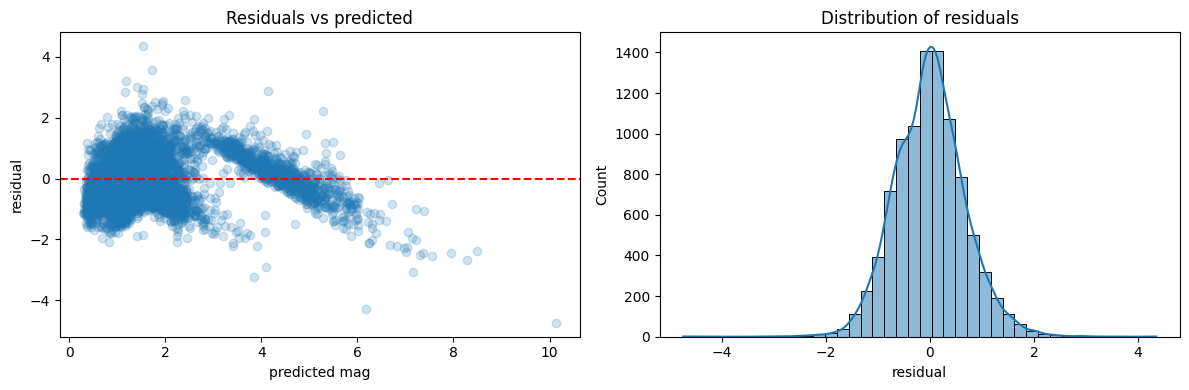

Mean residual: -0.0005 (should be near 0)
Lowest prediction: 0.3 | highest prediction: 10.14

Residuals grouped by the predicted magnitude:
         count  mean   std
(-5, 1]   2095 -0.19  0.55
(1, 2]    5821  0.07  0.63
(2, 3]     650 -0.10  0.93
(3, 4]     303  0.61  0.77
(4, 12]    582 -0.25  0.75


In [17]:
# 1.1 Residual analysis
lin = Pipeline([('impute', SimpleImputer(strategy='median')),
                ('model', LinearRegression())])
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# go over the 5 folds
y_pred = np.zeros(len(df))
for train_idx, val_idx in kf.split(X):
    lin.fit(X.iloc[train_idx], y_reg.iloc[train_idx])
    y_pred[val_idx] = lin.predict(X.iloc[val_idx])

residual = y_reg - y_pred            # residual = y - y_hat
abs_error = residual.abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residual, alpha=0.2)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals vs predicted")
axes[0].set_xlabel("predicted mag")
axes[0].set_ylabel("residual")

sns.histplot(residual, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("residual")

plt.tight_layout()
plt.show()

print("Mean residual:", round(residual.mean(), 4), "(should be near 0)")
print("Lowest prediction:", round(y_pred.min(), 2), "| highest prediction:", round(y_pred.max(), 2))

# group the residuals by the predicted value
bins = pd.cut(pd.Series(y_pred), bins=[-5, 1, 2, 3, 4, 12])
print()
print("Residuals grouped by the predicted magnitude:")
print(residual.groupby(bins.values, observed=True).agg(['count', 'mean', 'std']).round(2))

# 1.1 Residual analysis

- **Centered at zero?** Yes. The mean residual is -0.0005, basically 0. This is expected from linear regression, it fits the mean, so on average it is not biased. But an average of 0 hides a lot, as the plot shows.
- **Systematic patterns?** The "residuals vs predicted" plot is not a clean cloud. Above a prediction of about 5 all the points are under the red line and they sit on a diagonal going down. That means the model predict too high for these events, and the higher it predicts the worse it gets. The grouped table shows the same thing in numbers: the mean residual is +0.61 for predictions between 3 and 4, and -0.25 for predictions above 4.
- **Heteroscedasticity?** Yes, the variance is not constant. The std of the residuals is 0.55 for predictions under 1, and 0.93 for predictions between 2 and 3. So the model is not only more wrong on the bigger events, it is also less stable there.
- The histogram is symmetric and looks like a bell, but with tails that are a bit too long (there are errors of more than 4 magnitude units). I check this with numbers in 1.4.

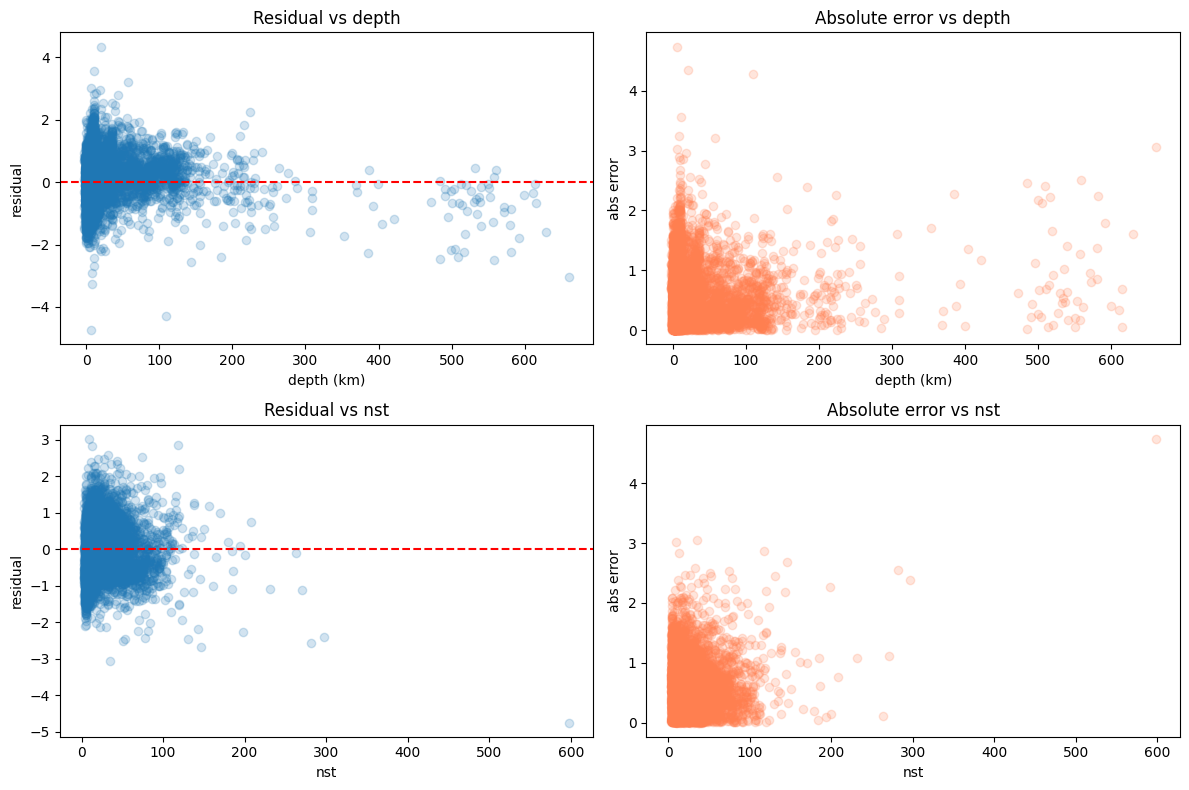

Mean absolute error by depth:
           count   mean
depth                  
(-5, 5]     3370  0.444
(5, 10]     2933  0.564
(10, 20]    1235  0.574
(20, 50]     906  0.576
(50, 700]   1007  0.537

Mean absolute error by nst:
           count   mean
nst                    
(0, 10]     1920  0.573
(10, 20]    2222  0.476
(20, 40]    1961  0.491
(40, 80]    1005  0.577
(80, 700]    211  0.695

Mean abs error for depth exactly 10 km: 0.773 | all the other rows: 0.509


In [18]:
# 1.2 Error as a function of features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(df['depth'], residual, alpha=0.2)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("Residual vs depth")
axes[0, 0].set_xlabel("depth (km)")
axes[0, 0].set_ylabel("residual")

axes[0, 1].scatter(df['depth'], abs_error, alpha=0.2, color='coral')
axes[0, 1].set_title("Absolute error vs depth")
axes[0, 1].set_xlabel("depth (km)")
axes[0, 1].set_ylabel("abs error")

axes[1, 0].scatter(df['nst'], residual, alpha=0.2)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual vs nst")
axes[1, 0].set_xlabel("nst")
axes[1, 0].set_ylabel("residual")

axes[1, 1].scatter(df['nst'], abs_error, alpha=0.2, color='coral')
axes[1, 1].set_title("Absolute error vs nst")
axes[1, 1].set_xlabel("nst")
axes[1, 1].set_ylabel("abs error")

plt.tight_layout()
plt.show()

# the same in numbers, by bins
print("Mean absolute error by depth:")
print(abs_error.groupby(pd.cut(df['depth'], [-5, 5, 10, 20, 50, 700]), observed=True).agg(['count', 'mean']).round(3))
print()
print("Mean absolute error by nst:")
print(abs_error.groupby(pd.cut(df['nst'], [0, 10, 20, 40, 80, 700]), observed=True).agg(['count', 'mean']).round(3))

# the 10 km placeholder I found in Homework 1 - does the model suffer from it?
print()
print("Mean abs error for depth exactly 10 km:", round(abs_error[df['depth'] == 10].mean(), 3),
      "| all the other rows:", round(abs_error[df['depth'] != 10].mean(), 3))

# 1.2 Error as a function of features

- **Depth:** Error grows from 0.44 (0-5 km) to 0.57 (10-50 km). Deep events (>300 km) are consistently over-predicted. This is a hidden subpopulation a single linear equation cannot fit.
- **nst:** Error is lowest in the middle (0.48) and highest at the ends (0.57 under 10, 0.70 over 80). As seen in HW1, `mag` and `nst` have a curved relationship, which a straight line cannot follow.
- **The 10 km placeholder:** Rows with depth exactly 10 km have a MAE of 0.773 vs 0.509 for others (~50% worse). The model gets a fake depth (USGS default from HW1) so it makes a worse prediciton. This is a data quality problem, not a model problem.

In [19]:
# 1.3 Analysis of extreme errors
threshold = abs_error.quantile(0.95)
mask = abs_error >= threshold

extreme = df.loc[mask, ['mag', 'depth', 'nst', 'net', 'type']].copy()
extreme['predicted'] = np.round(y_pred[mask.values], 2)
extreme['abs_error'] = abs_error[mask].round(2)

print("Absolute error of the top 5% starts at:", round(threshold, 3))
print("Number of extreme-error rows:", len(extreme))
print("Share of them with mag >= 3:", round((extreme['mag'] >= 3).mean(), 3),
      "| share in the whole data:", round((df['mag'] >= 3).mean(), 3))
print("Extreme rows whose nst was missing (so it got the median):", int(extreme['nst'].isna().sum()))
print("Over-predicted:", int((residual[mask] < 0).sum()), "| under-predicted:", int((residual[mask] > 0).sum()))
print()

print("Which networks are they from?")
print(extreme['net'].value_counts().head(5))
print()

print("The 5 worst errors:")
print(extreme.sort_values('abs_error', ascending=False).head())

Absolute error of the top 5% starts at: 1.317
Number of extreme-error rows: 473
Share of them with mag >= 3: 0.522 | share in the whole data: 0.122
Extreme rows whose nst was missing (so it got the median): 118
Over-predicted: 196 | under-predicted: 277

Which networks are they from?
net
us    145
ak    118
av     50
nn     41
uu     27
Name: count, dtype: int64

The 5 worst errors:
      mag  depth    nst net        type  predicted  abs_error
6987  5.4    6.0  598.0  us  earthquake      10.14       4.74
4200  5.9   20.2    NaN  ak  earthquake       1.55       4.35
4566  1.9  109.1    NaN  ak  earthquake       6.18       4.28
2162  5.3   10.5    NaN  ak  earthquake       1.73       3.57
1921  0.6    7.7    NaN  ak  earthquake       3.85       3.25


# 1.3 Analysis of extreme errors

The top 5% (473 rows) have an absolute error of 1.32 or more. The big events (mag >= 3) are 52.2% of this group, compared to only 12.2% in the whole data. They are highly over-represented. Looking at the rows, I see the three causes from the assignment:

*   **Rare cases:** The model is trained mostly on tiny events, so its never learns the top of the scale. 277 of the extreme rows are under-predicted.
*   **Data quality:** 118 extreme rows are `ak` events where `nst` was missing and got the median. The model predicts from a made up value. For example, a mag 5.9 event was predicted as 1.55. This is exactly the risk I wrote about in HW1, and here I see the price of it.
*   **Model limitation:** The worst error is a mag 5.4 event predicted as **10.14** because it had nst = 598. The linear model just continued its straight line up. But 10.14 is not physically possible, a linear model has no way to know the target has a celing.

The errors go in both directions (196 over, 277 under), so it is a mix of these three causes and not one simple bias.

In [20]:
# 1.4 Statistical properties of the errors
print("MAE:", round(mean_absolute_error(y_reg, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_reg, y_pred)), 3))
print("R2:", round(r2_score(y_reg, y_pred), 3))
print()
print("Std of the residuals:", round(residual.std(), 3))
print("Skewness of the residuals:", round(residual.skew(), 3))
print("Kurtosis of the residuals:", round(residual.kurtosis(), 3))
print()
print("Std of the target itself (for comparison):", round(y_reg.std(), 3))

MAE: 0.521
RMSE: 0.673
R2: 0.704

Std of the residuals: 0.674
Skewness of the residuals: 0.132
Kurtosis of the residuals: 1.251

Std of the target itself (for comparison): 1.238


# 1.4 Statistical properties of the errors

- **MAE = 0.521 and std of the residuals = 0.674:** The target std is 1.238, so the model explains part of the variation (R2 = 0.704). But missing by half a magnitude is a lot on a logarithmic scale, half a unit is about a factor of 5 in energy.
- **Skewness = 0.132:** The residuals are nearly symmetric, which fits the mean residual of ~0.
- **Kurtosis = 1.251:** Pandas gives 0 for a normal distribution, so the tails here are heavy. This means a few rows have much larger errors (the extreme rows from 1.3). This is also why RMSE (0.673) is bigger than MAE (0.521), and RMSE squares the errors so it punish the rare big misses.

The "average" numbers look reasonable, but the tails are the real problem. This is why the assignment asks for error analysis and not only for one score.

# 2. Regression models

I limit the Decision Tree to `max_depth=8` because a full tree overfits. I also check the MAE on the `mag >= 3` rows alone, because section 1 showed that this is where the baseline breaks.

In [21]:
# 2. Regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=0)
}

rows = []
predictions = {}

for name, model in models.items():
    pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('model', model)])
    pred = np.zeros(len(df))
    for train_idx, val_idx in kf.split(X):
        pipe.fit(X.iloc[train_idx], y_reg.iloc[train_idx])
        pred[val_idx] = pipe.predict(X.iloc[val_idx])

    predictions[name] = pred
    mse = mean_squared_error(y_reg, pred)
    rows.append({'model': name,
                 'MSE': round(mse, 3),
                 'RMSE': round(np.sqrt(mse), 3),
                 'MAE': round(mean_absolute_error(y_reg, pred), 3),
                 'R2': round(r2_score(y_reg, pred), 3)})

print(pd.DataFrame(rows).set_index('model'))
print()

big = (y_reg >= 3)
print("MAE on mag >= 3 rows:")
for name, pred in predictions.items():
    print(name, ":", round(mean_absolute_error(y_reg[big], pred[big]), 3))

print()
print("Highest prediction:")
for name, pred in predictions.items():
    print(name, ":", round(pred.max(), 2))

                     MSE   RMSE    MAE     R2
model                                        
Linear Regression  0.454  0.673  0.521  0.704
Decision Tree      0.212  0.460  0.332  0.862
Random Forest      0.138  0.372  0.263  0.910

MAE on mag >= 3 rows:
Linear Regression : 0.849
Decision Tree : 0.4
Random Forest : 0.322

Highest prediction:
Linear Regression : 10.14
Decision Tree : 7.0
Random Forest : 6.05


# 2. Regression models - discussion

* **Performance & Preferred Model:** The Random Forest is the winner. It reaches R2 = 0.910 and cuts the MAE on big events from 0.849 (linear) down to 0.322. I choose it for the future analysis.
* **Assumptions:** The linear assumptions are not satisfied. Section 1 showed heteroscedasticity and a curved relation with `nst`.
* **Outliers and noise:** The linear model is very sensitive. One outlier makes it predict 10.14, which is impossible. Tree models are much safer (highest prediction is 6.05).
* **Bias-Variance & Trees vs Linear:** The linear model has high bias (too simple). A full tree has high variance (memorizes the data). The Random Forest is a good balance. Trees are better here because they follow the non-linear shape and give diffrent rules to deep events.
* **Interpretability:** The linear model is easy to explain but fails on the important events. The forest is harder to explain but actually works.
* **What I learned:** An average score like R2 = 0.704 can hide the real failure, like the 10.14 prediction.

# 3. classification error analysis


I use Logistic Regression with StandardScaler. I chose it because it gives probalities for sections 3.2 and 3.4. I use StratifiedKFold to keep the 12.2% class balance in the folds.

TN: 8258 FP: 38 FN: 175 TP: 980
accuracy: 0.977
baseline: 0.878
precision: 0.963
recall: 0.848
f1: 0.902


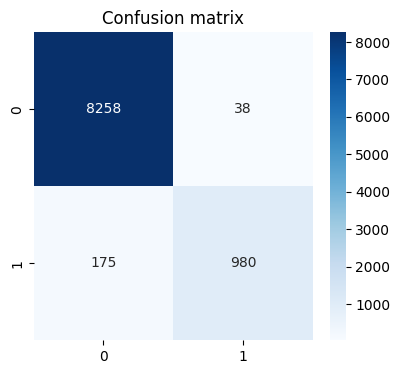

errors on the border: 158 from 213

false negatives mag:
count    175.00
mean       3.42
std        0.45
min        3.00
25%        3.10
50%        3.30
75%        3.50
max        5.90
Name: mag, dtype: float64

false positives mag:
count    38.00
mean      2.48
std       0.56
min       0.60
25%       2.30
50%       2.75
75%       2.88
max       2.92
Name: mag, dtype: float64


In [22]:
# 3.1 Confusion matrix
clf = Pipeline([('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# oof loop for classification
proba = np.zeros(len(df))
for train_idx, val_idx in skf.split(X, y_clf):
    clf.fit(X.iloc[train_idx], y_clf.iloc[train_idx])
    proba[val_idx] = clf.predict_proba(X.iloc[val_idx])[:, 1]

pred_05 = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_clf, pred_05)
tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

print("accuracy:", round(accuracy_score(y_clf, pred_05), 3))
print("baseline:", round(1 - y_clf.mean(), 3))
print("precision:", round(precision_score(y_clf, pred_05), 3))
print("recall:", round(recall_score(y_clf, pred_05), 3))
print("f1:", round(f1_score(y_clf, pred_05), 3))

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix")
plt.show()

# check where the mistakes are
wrong = (pred_05 != y_clf)
wrong_count = wrong.sum()
border_errors = ((df['mag'] >= 2.5) & (df['mag'] <= 3.5) & wrong).sum()
print("errors on the border:", border_errors, "from", wrong_count)
print()
print("false negatives mag:")
print(df.loc[(y_clf == 1) & (pred_05 == 0), 'mag'].describe().round(2))
print()
print("false positives mag:")
print(df.loc[(y_clf == 0) & (pred_05 == 1), 'mag'].describe().round(2))

# 3.1 Confusion matrix

* **Most critical error:** False negative. Missing a felt earthquake is worse than a false alert.
* **Systematic failure regions:** Around the 3.0 boundary. The false negatives have a median magnitude of 3.3, and false positives are up to 2.92.
* **Insights:** The formulation is the problem. An event of 2.98 and 3.02 are practically the same but get oppsoite labels.

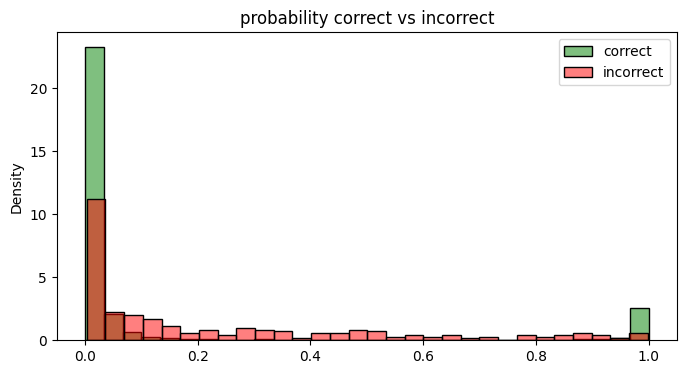

wrong predictions: 213
median probability of errors: 0.097

confident errors share: 0.7
confident correct share: 0.982

errors under 0.2: 132
errors over 0.8: 17


In [23]:
# 3.2 Probability based analysis
correct = (pred_05 == y_clf)
wrong = (pred_05 != y_clf)

plt.figure(figsize=(8, 4))
sns.histplot(proba[correct], bins=30, color='green', label='correct', stat='density', alpha=0.5)
sns.histplot(proba[wrong], bins=30, color='red', label='incorrect', stat='density', alpha=0.5)
plt.title("probability correct vs incorrect")
plt.legend()
plt.show()

err_proba = proba[wrong]
ok_proba = proba[correct]

print("wrong predictions:", wrong.sum())
print("median probability of errors:", round(np.median(err_proba), 3))

# check confident predictions (far from 0.5)
conf_err = ((err_proba < 0.2) | (err_proba > 0.8)).mean()
conf_ok = ((ok_proba < 0.2) | (ok_proba > 0.8)).mean()

print()
print("confident errors share:", round(conf_err, 3))
print("confident correct share:", round(conf_ok, 3))
print()
print("errors under 0.2:", (err_proba < 0.2).sum())
print("errors over 0.8:", (err_proba > 0.8).sum())

# 3.2 Probability based analysis

* **Correct vs Incorrect:** 98.2% of the correct predictions are confident, but 70% of the errors are also confident (under 0.2 or over 0.8).
* **High-confidence errors:** 132 errors got a probability below 0.2. The model confidently predicts "not significant" for real significant events.
* **Reason:** This happens because of the class imbalence. Since only 12.2% of the rows are positive, the model learns to just guess the negative class with high confidence.

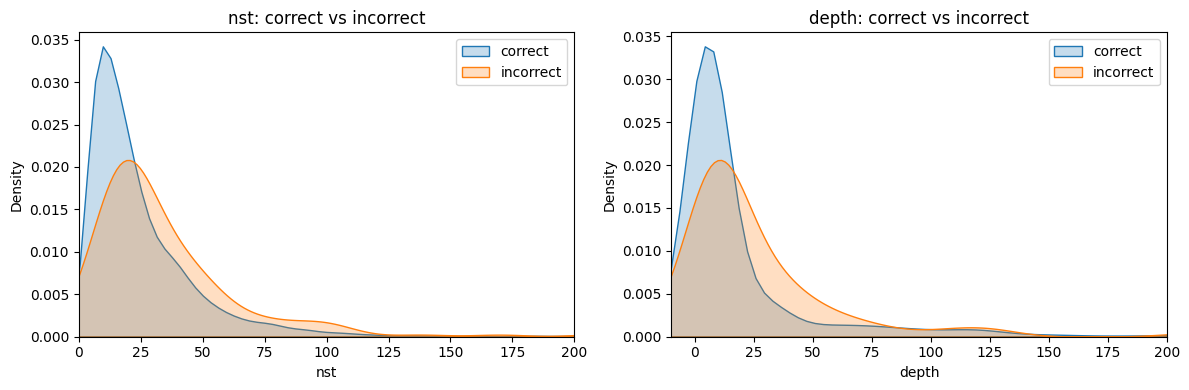

correct predictions stats:
         nst  depth
mean    24.6   21.2
median  18.0    7.1

wrong predictions stats:
         nst  depth
mean    34.5   27.5
median  24.0   10.5

Error rate for big networks:
ak : 0.03 (size: 2132 )
nc : 0.004 (size: 1602 )
ci : 0.009 (size: 1063 )
us : 0.064 (size: 1053 )
nn : 0.005 (size: 642 )
tx : 0.034 (size: 623 )


In [24]:
# 3.3 Error as a function of features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df.loc[correct, 'nst'].dropna(), label='correct', fill=True, ax=axes[0])
sns.kdeplot(df.loc[wrong, 'nst'].dropna(), label='incorrect', fill=True, ax=axes[0])
axes[0].set_title("nst: correct vs incorrect")
axes[0].set_xlim(0, 200)
axes[0].legend()

sns.kdeplot(df.loc[correct, 'depth'].dropna(), label='correct', fill=True, ax=axes[1])
sns.kdeplot(df.loc[wrong, 'depth'].dropna(), label='incorrect', fill=True, ax=axes[1])
axes[1].set_title("depth: correct vs incorrect")
axes[1].set_xlim(-10, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

# simple check of median and mean
print("correct predictions stats:")
print(df.loc[correct, ['nst', 'depth']].agg(['mean', 'median']).round(1))
print()
print("wrong predictions stats:")
print(df.loc[wrong, ['nst', 'depth']].agg(['mean', 'median']).round(1))
print()

# error rate by network
df['wrong'] = wrong
net_errors = df.groupby('net')['wrong'].mean()
net_counts = df['net'].value_counts()

print("Error rate for big networks:")
for net in ['ak', 'nc', 'ci', 'us', 'nn', 'tx']:
    print(net, ":", round(net_errors[net], 3), "(size:", net_counts[net], ")")

# 3.3 Error as a function of features

* **nst:** Events with higher `nst` are misclassified more. The median `nst` is 18 for correct and 24 for incorrect.
* **depth:** Deeper events have more errors (median depth 10.5 km vs 7.1 km).
* **Network:** The `us` network has an error rate of 6.4%, while `nc` is only 0.4%. This is a diffrence of more than 10 times.
* **Insight:** The model fails on the `us` network becuase it reports the global, stronger events. The `nc` and `ci` networks are in California and report tiny quakes that are easy to classify as "not significant". The coverage bias from HW1 creates regions where the model fails.

 threshold  precision  recall    f1   MCC
       0.1      0.782   0.907 0.840 0.819
       0.2      0.887   0.886 0.886 0.871
       0.3      0.924   0.872 0.897 0.884
       0.4      0.957   0.861 0.906 0.895
       0.5      0.963   0.848 0.902 0.892
       0.6      0.972   0.830 0.895 0.886
       0.7      0.977   0.806 0.883 0.874
       0.8      0.982   0.784 0.872 0.863
       0.9      0.991   0.747 0.852 0.845


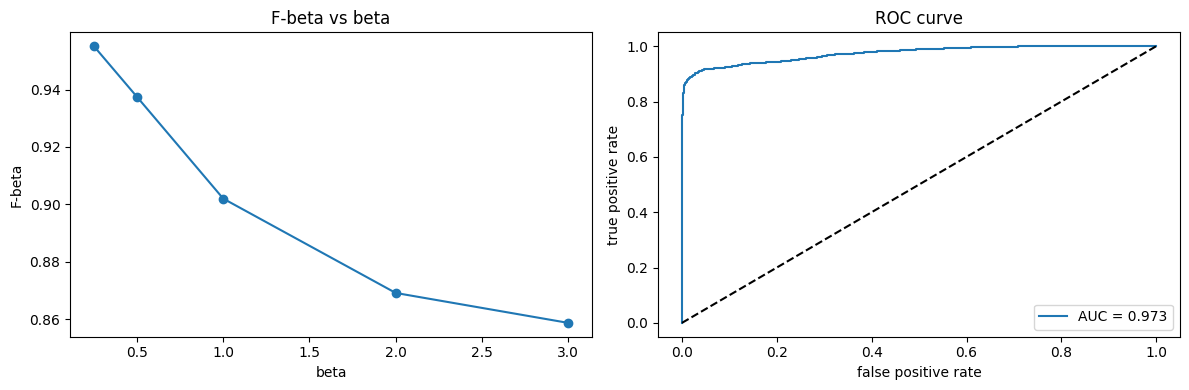

AUC-ROC: 0.973

Logistic Regression: AUC 0.973 | recall 0.848
Random Forest: AUC 0.983 | recall 0.873


In [25]:
# 3.4 Threshold sensitivity analysis
thresholds = np.arange(0.1, 1.0, 0.1)
rows = []
for t in thresholds:
    p = (proba >= t).astype(int)
    rows.append({'threshold': round(t, 1),
                 'precision': round(precision_score(y_clf, p, zero_division=0), 3),
                 'recall': round(recall_score(y_clf, p, zero_division=0), 3),
                 'f1': round(f1_score(y_clf, p, zero_division=0), 3),
                 'MCC': round(matthews_corrcoef(y_clf, p), 3)})

print(pd.DataFrame(rows).to_string(index=False))

# F-beta and ROC
betas = [0.25, 0.5, 1, 2, 3]
fbetas = [fbeta_score(y_clf, pred_05, beta=b, zero_division=0) for b in betas]
fpr, tpr, _ = roc_curve(y_clf, proba)
auc = roc_auc_score(y_clf, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(betas, fbetas, marker='o')
axes[0].set_title("F-beta vs beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("F-beta")

axes[1].plot(fpr, tpr, label="AUC = " + str(round(auc, 3)))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("ROC curve")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].legend()

plt.tight_layout()
plt.show()

print("AUC-ROC:", round(auc, 3))
print()

# Random forest comparison
rf_clf = Pipeline([('impute', SimpleImputer(strategy='median')),
                   ('model', RandomForestClassifier(n_estimators=100, random_state=0))])
rf_proba = np.zeros(len(df))
for train_idx, val_idx in skf.split(X, y_clf):
    rf_clf.fit(X.iloc[train_idx], y_clf.iloc[train_idx])
    rf_proba[val_idx] = rf_clf.predict_proba(X.iloc[val_idx])[:, 1]

rf_pred = (rf_proba >= 0.5).astype(int)
print("Logistic Regression: AUC", round(auc, 3), "| recall", round(recall_score(y_clf, pred_05), 3))
print("Random Forest: AUC", round(roc_auc_score(y_clf, rf_proba), 3),
      "| recall", round(recall_score(y_clf, rf_pred), 3))

# 3.4 Threshold sensitivity analysis

* **The trade off:** Moving the threshold changes precision and recall in opposite directions. For an alert system I would choose 0.3 or 0.4. Catching more real earthquakes (higher recall) is worth the price of a few more false alarms.
* **Stable and unstable regions:** The region between 0.3 and 0.6 is very stable for both F1 and MCC. The edges are unstable - moving from 0.1 to 0.2 makes the precision jump by more than 10 points.
* **F-beta:** The curve goes down as beta goes up. Beta weights recall higher, and our recall is the weaker metric.
* **Model comparison:** The Random Forest gets a better AUC (0.983 vs 0.973) and better recall. This is similar to what happend in the regression task.

# 3.5 Discussion

* **Strengths and limitations:** Linear and logistic models are simple and fast, but they assume a straight line. Tree models fit the data much better, but they are harder to interpet.
* **Failure modes:** The model fails on rare big events (the tail), imputed `ak` rows, the 10 km depth placeholder, and events exactly on the mag=3 boundary. It also fails much more on the global `us` network.
* **Assumptions vs performance:** The data is not linear, which is why the linear model predicted an impossible 10.14 magnitude. The data is also imbalanced, which makes the false negatives confident.
* **Significant insights:** The worst errors come from data quality (like the fake medians) and the problem formulation, not from the algorithm itself.
* **Recommendations:**
  * Use Random Forest as the main model.
  * Add a missing indicator column for the imputed `nst` and `dmin` features.
  * Lower the classification threshold to 0.3 or 0.4.
  * Drop the `nst` feature if we want to build a real forecasting system.
  * Train on more months of data to see more large earthquakes.

# 4. Final reflection

1. **Where does the model fail most?** On the rare and strong events. They are 52% of the worst errors but only 12% of the data. It also fails on rows with imputed features.
2. **Data, model, or formulation?** All three. Data: missing values and the 10 km placeholder. Model: a linear model has no celing (predicting 10.14). Formulation: cutting the target at exactly 3.0 makes the border impossible to get right.
3. **Proposed improvements:** I would add a missing value indicator column so the model knows when a value is fake. I would also lower the classification threshold to 0.3.
4. **Insights gained:** A good average score can hide the real problems. The 97.7% accuracy hides 175 missed earthquakes.